# GAM Pipeline — Nested Resampling, Full-Data Retuning, and Manifest Export


## 1. Imports and Configuration


In [5]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'data_modelling').exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError('Could not locate repo src/ directory for notebook imports.')


In [6]:
# Core libraries
import warnings
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

import optuna
from pygam import LinearGAM, GammaGAM, s

from data_modelling.common_metrics import regression_metrics, rmse, to_original_scale
from data_modelling.prepared_data import load_prepared_data, prepare_dual_target_model_data
from data_modelling.training_outputs import (
    build_oof_frame,
    build_oof_metrics_df,
    build_run_manifest,
    summarize_nested_cv,
    write_manifest,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam'
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
PREPARED_TARGET_COL = 'ml_ade'
DATA_PATH = Path('../../results/interpretable_model/prepared_data') / RUN_NAME / f'prepared_data_{PREPARED_TARGET_COL}.csv'
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log' or 'ml_ade'

RANDOM_STATE = 42
k_outer_fold = 5
k_inner_fold = 3
N_OPTUNA_TRIALS = 40
POOR_WELL_QUANTILE = 0.20
MIN_SPLINES = 10
MAX_SPLINES = 25
MIN_SPLINE_ORDER = 3
MAX_SPLINE_ORDER = 4
MIN_LAM = 1e-3
MAX_LAM = 1e3
TUNING_METRIC = 'rmse'

SAVE_DIR = Path('../../results/interpretable_model') / MODEL_ID / RUN_NAME
PLOTS_DIR = SAVE_DIR / 'plots'
TABLES_DIR = SAVE_DIR / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports and configuration loaded.')
print(f'Run: {RUN_NAME}')
print(f'Model ID: {MODEL_ID}')
print('Interpretable model: GAM')
print(f'DATA_PATH: {DATA_PATH}')
print(f'SAVE_DIR:  {SAVE_DIR.resolve()}')
print(
    'Nested CV: '
    f'outer={k_outer_fold}, inner={k_inner_fold}, optuna_trials={N_OPTUNA_TRIALS}'
)


Imports and configuration loaded.
Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID: gam
Interpretable model: GAM
DATA_PATH: ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
SAVE_DIR:  /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Nested CV: outer=5, inner=3, optuna_trials=40


## 2. Load Prepared Data and Resolve Targets


In [7]:
df = load_prepared_data(DATA_PATH, display_fn=display)

prepared = prepare_dual_target_model_data(
    df,
    target_col=TARGET_COL,
    default_target='ml_ade',
)
raw_target_col = prepared['raw_target_col']
log_target_col = prepared['log_target_col']
target_col = prepared['target_col']
feature_cols = prepared['feature_cols']
model_df = prepared['model_df']
X = prepared['X']
y_raw = prepared['y_raw']
y_log = prepared['y_log']
row_ids = prepared['row_ids']
n_features = prepared['n_features']

print(f'Raw target column: {raw_target_col}')
print(f'Log target column: {log_target_col}')
print(f'Primary target column for nested resampling: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Rows available for modeling: {len(model_df)}')
print(f'Feature matrix shape: {X.shape}')
print(f'Raw target shape: {y_raw.shape}')
print(f'Log target shape: {y_log.shape}')


Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340


Raw target column: ml_ade
Log target column: ml_ade_log
Primary target column for nested resampling: ml_ade_log
Number of features: 13
Rows available for modeling: 451
Feature matrix shape: (451, 13)
Raw target shape: (451,)
Log target shape: (451,)


## 3. Shared Helpers


In [8]:
def build_gam_terms(n_features, n_splines, spline_order):
    terms = s(0, n_splines=n_splines, spline_order=spline_order)
    for idx in range(1, n_features):
        terms += s(idx, n_splines=n_splines, spline_order=spline_order)
    return terms


def fit_gam_model(model_kind, X_train_scaled, y_train, params):
    terms = build_gam_terms(
        n_features=X_train_scaled.shape[1],
        n_splines=int(params['n_splines']),
        spline_order=int(params['spline_order']),
    )
    if model_kind == 'linear':
        model = LinearGAM(terms, lam=float(params['lam']))
    elif model_kind == 'gamma':
        model = GammaGAM(terms, lam=float(params['lam']))
    else:
        raise ValueError(f'Unsupported model_kind={model_kind}')

    model.fit(X_train_scaled, y_train)
    return model


def evaluate_variant_cv(X_values, y_values, *, model_kind, target_mode, params, seed, variant_name):
    cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
    fold_rows = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_values), start=1):
        X_train = X_values[train_idx]
        X_valid = X_values[valid_idx]
        y_train = y_values[train_idx]
        y_valid = y_values[valid_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        model = fit_gam_model(model_kind, X_train_scaled, y_train, params)
        y_pred = model.predict(X_valid_scaled)
        y_valid_orig = to_original_scale(y_valid, target_mode=target_mode)
        y_pred_orig = to_original_scale(y_pred, target_mode=target_mode)
        metrics = regression_metrics(y_valid_orig, y_pred_orig)

        fold_rows.append({
            'variant_name': variant_name,
            'fold': fold_idx,
            'R²': metrics['R²'],
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
        })

    fold_metrics_df = pd.DataFrame(fold_rows)
    summary = {
        'cv_r2_mean': float(fold_metrics_df['R²'].mean()),
        'cv_r2_std': float(fold_metrics_df['R²'].std(ddof=1)),
        'cv_mae_mean': float(fold_metrics_df['MAE'].mean()),
        'cv_mae_std': float(fold_metrics_df['MAE'].std(ddof=1)),
        'cv_rmse_mean': float(fold_metrics_df['RMSE'].mean()),
        'cv_rmse_std': float(fold_metrics_df['RMSE'].std(ddof=1)),
    }

    return {
        'fold_metrics_df': fold_metrics_df,
        'summary': summary,
    }


def run_gam_optuna_tuning(X_values, y_values, *, model_kind, target_mode, seed, tuning_scope, variant_name):
    trial_rows = []

    def objective(trial):
        params = {
            'n_splines': trial.suggest_int('n_splines', MIN_SPLINES, MAX_SPLINES),
            'spline_order': trial.suggest_int('spline_order', MIN_SPLINE_ORDER, MAX_SPLINE_ORDER),
            'lam': trial.suggest_float('lam', MIN_LAM, MAX_LAM, log=True),
        }

        inner_cv = KFold(n_splits=k_inner_fold, shuffle=True, random_state=seed)
        fold_rmses = []

        for inner_train_idx, inner_valid_idx in inner_cv.split(X_values):
            X_inner_train = X_values[inner_train_idx]
            X_inner_valid = X_values[inner_valid_idx]
            y_inner_train = y_values[inner_train_idx]
            y_inner_valid = y_values[inner_valid_idx]

            scaler = StandardScaler()
            X_inner_train_scaled = scaler.fit_transform(X_inner_train)
            X_inner_valid_scaled = scaler.transform(X_inner_valid)

            try:
                model = fit_gam_model(model_kind, X_inner_train_scaled, y_inner_train, params)
                y_inner_pred = model.predict(X_inner_valid_scaled)
                y_inner_valid_orig = to_original_scale(y_inner_valid, target_mode=target_mode)
                y_inner_pred_orig = to_original_scale(y_inner_pred, target_mode=target_mode)
                fold_rmses.append(rmse(y_inner_valid_orig, y_inner_pred_orig))
            except Exception:
                fold_rmses.append(float('inf'))

        mean_cv_rmse = float(np.mean(fold_rmses))
        row = {
            'variant_name': variant_name,
            'tuning_scope': tuning_scope,
            'trial_number': trial.number,
            'mean_cv_rmse': mean_cv_rmse,
            'n_splines': int(params['n_splines']),
            'spline_order': int(params['spline_order']),
            'lam': float(params['lam']),
        }
        trial_rows.append(row)
        return mean_cv_rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    trial_results_df = pd.DataFrame(trial_rows).sort_values('mean_cv_rmse').reset_index(drop=True)
    best_params = {
        'n_splines': int(study.best_params['n_splines']),
        'spline_order': int(study.best_params['spline_order']),
        'lam': float(study.best_params['lam']),
    }
    best_cv_rmse = float(study.best_value)

    print(
        f'{variant_name} | {tuning_scope} tuning complete | '
        f'best_cv_rmse={best_cv_rmse:.6f}'
    )

    return {
        'best_params': best_params,
        'best_cv_rmse': best_cv_rmse,
        'trial_results_df': trial_results_df,
    }


## 4. Nested Resampling for `LinearGAM (log)`


In [9]:
outer_cv = KFold(n_splits=k_outer_fold, shuffle=True, random_state=RANDOM_STATE)
n_samples = len(model_df)
oof_pred = np.full(n_samples, np.nan, dtype=float)
oof_fold = np.full(n_samples, -1, dtype=int)

nested_rows = []

for fold_idx, (outer_train_idx, outer_valid_idx) in enumerate(outer_cv.split(X, y_log), start=1):
    X_outer_train = X[outer_train_idx]
    X_outer_valid = X[outer_valid_idx]
    y_outer_train = y_log[outer_train_idx]
    y_outer_valid_raw = y_raw[outer_valid_idx]

    tuning_result = run_gam_optuna_tuning(
        X_outer_train,
        y_outer_train,
        model_kind='linear',
        target_mode='log',
        seed=RANDOM_STATE + fold_idx,
        tuning_scope=f'outer_fold_{fold_idx}',
        variant_name='LinearGAM (log)',
    )

    scaler = StandardScaler()
    X_outer_train_scaled = scaler.fit_transform(X_outer_train)
    X_outer_valid_scaled = scaler.transform(X_outer_valid)
    outer_model = fit_gam_model('linear', X_outer_train_scaled, y_outer_train, tuning_result['best_params'])

    outer_pred_log = outer_model.predict(X_outer_valid_scaled)
    oof_pred[outer_valid_idx] = outer_pred_log
    oof_fold[outer_valid_idx] = fold_idx

    outer_pred_orig = to_original_scale(outer_pred_log, target_mode='log')
    outer_metrics = regression_metrics(y_outer_valid_raw, outer_pred_orig)

    row = {
        'outer_fold': fold_idx,
        'outer_rmse': outer_metrics['RMSE'],
        'outer_mae': outer_metrics['MAE'],
        'outer_r2': outer_metrics['R²'],
        'inner_best_cv_rmse': tuning_result['best_cv_rmse'],
    }
    row.update({f'best_{k}': v for k, v in tuning_result['best_params'].items()})
    nested_rows.append(row)

    print(
        f'Outer fold {fold_idx}/{k_outer_fold} | '
        f"RMSE={outer_metrics['RMSE']:.6f} | MAE={outer_metrics['MAE']:.6f} | R2={outer_metrics['R²']:.4f}"
    )

if np.isnan(oof_pred).any():
    raise ValueError('OOF predictions contain NaN values. Check CV splits and training flow.')

nested_cv_df = pd.DataFrame(nested_rows)
display(nested_cv_df)

nested_summary = summarize_nested_cv(nested_cv_df)
print('Nested CV summary:')
display(nested_summary)

nested_path = TABLES_DIR / f'nested_cv_optuna_{target_col}.csv'
nested_summary_path = TABLES_DIR / f'nested_cv_optuna_summary_{target_col}.csv'
nested_cv_df.to_csv(nested_path, index=False)
nested_summary.to_csv(nested_summary_path, index=False)
print(f'Nested CV fold results saved to: {nested_path}')
print(f'Nested CV summary saved to:      {nested_summary_path}')

model_df_oof = build_oof_frame(
    model_df,
    row_ids=row_ids,
    oof_pred=oof_pred,
    oof_fold=oof_fold,
    target_orig=model_df[raw_target_col].to_numpy(),
    pred_scale_kwargs={'target_mode': 'log'},
)

oof_path = TABLES_DIR / f'oof_predictions_{target_col}.csv'
model_df_oof[['row_id', 'oof_pred', 'oof_pred_orig', 'target_orig', 'outer_fold']].to_csv(oof_path, index=False)
print(f'OOF predictions saved to: {oof_path}')

metrics_df = build_oof_metrics_df(y_log, oof_pred, target_mode='log')
display(metrics_df)

metrics_path = TABLES_DIR / f'metrics_oof_{target_col}.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'OOF metrics saved to: {metrics_path}')


LinearGAM (log) | outer_fold_1 tuning complete | best_cv_rmse=0.419872
Outer fold 1/5 | RMSE=0.364141 | MAE=0.262420 | R2=0.5760
LinearGAM (log) | outer_fold_2 tuning complete | best_cv_rmse=0.384972
Outer fold 2/5 | RMSE=0.406437 | MAE=0.293363 | R2=0.5274
LinearGAM (log) | outer_fold_3 tuning complete | best_cv_rmse=0.418414
Outer fold 3/5 | RMSE=0.396167 | MAE=0.290715 | R2=0.5761
LinearGAM (log) | outer_fold_4 tuning complete | best_cv_rmse=0.414745
Outer fold 4/5 | RMSE=0.387854 | MAE=0.309666 | R2=0.3995
LinearGAM (log) | outer_fold_5 tuning complete | best_cv_rmse=0.395099
Outer fold 5/5 | RMSE=0.406602 | MAE=0.282913 | R2=0.5849


,outer_fold,outer_rmse,outer_mae,outer_r2,inner_best_cv_rmse,best_n_splines,best_spline_order,best_lam
0,1,0.364141,0.262420,0.575998,0.419872,19,4,2.964303
1,2,0.406437,0.293363,0.527386,0.384972,20,3,3.507987
2,3,0.396167,0.290715,0.576141,0.418414,17,4,964.176578
3,4,0.387854,0.309666,0.399517,0.414745,17,3,11.037770
4,5,0.406602,0.282913,0.584935,0.395099,14,3,0.588214


Nested CV summary:


,metric,mean,std
0,outer_rmse,0.392240,0.017550
1,outer_mae,0.287815,0.017216
2,outer_r2,0.532795,0.077872


Nested CV fold results saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/nested_cv_optuna_ml_ade_log.csv
Nested CV summary saved to:      ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/nested_cv_optuna_summary_ml_ade_log.csv
OOF predictions saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/oof_predictions_ml_ade_log.csv


,Split,R²,MAE,RMSE
0,OOF,0.54506,0.287759,0.392494


OOF metrics saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv


## 5. Full-Data Retuning Across GAM Variants


LinearGAM (log) | full_data tuning complete | best_cv_rmse=0.378279
LinearGAM (no log) | full_data tuning complete | best_cv_rmse=0.398714
GammaGAM | full_data tuning complete | best_cv_rmse=0.372144
Selected GAM variant based on lowest CV RMSE on original scale:
{'variant_name': 'GammaGAM', 'model_kind': 'gamma', 'target_mode': 'raw', 'status': 'completed', 'best_params': {'n_splines': 14, 'spline_order': 3, 'lam': 1.5257162491903473}, 'best_cv_rmse': 0.372143732178377, 'cv_r2_mean': 0.5346847256855711, 'cv_r2_std': 0.09162101381204242, 'cv_mae_mean': 0.28588224055256756, 'cv_mae_std': 0.03284323259699599, 'cv_rmse_mean': 0.394325180023323, 'cv_rmse_std': 0.03417337924261215}


,variant_name,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,best_cv_rmse
0,LinearGAM (no log),0.552139,0.043851,0.294161,0.012959,0.386869,0.015278,0.398714
1,GammaGAM,0.534685,0.091621,0.285882,0.032843,0.394325,0.034173,0.372144
2,LinearGAM (log),0.491600,0.021823,0.296914,0.003182,0.414285,0.014903,0.378279


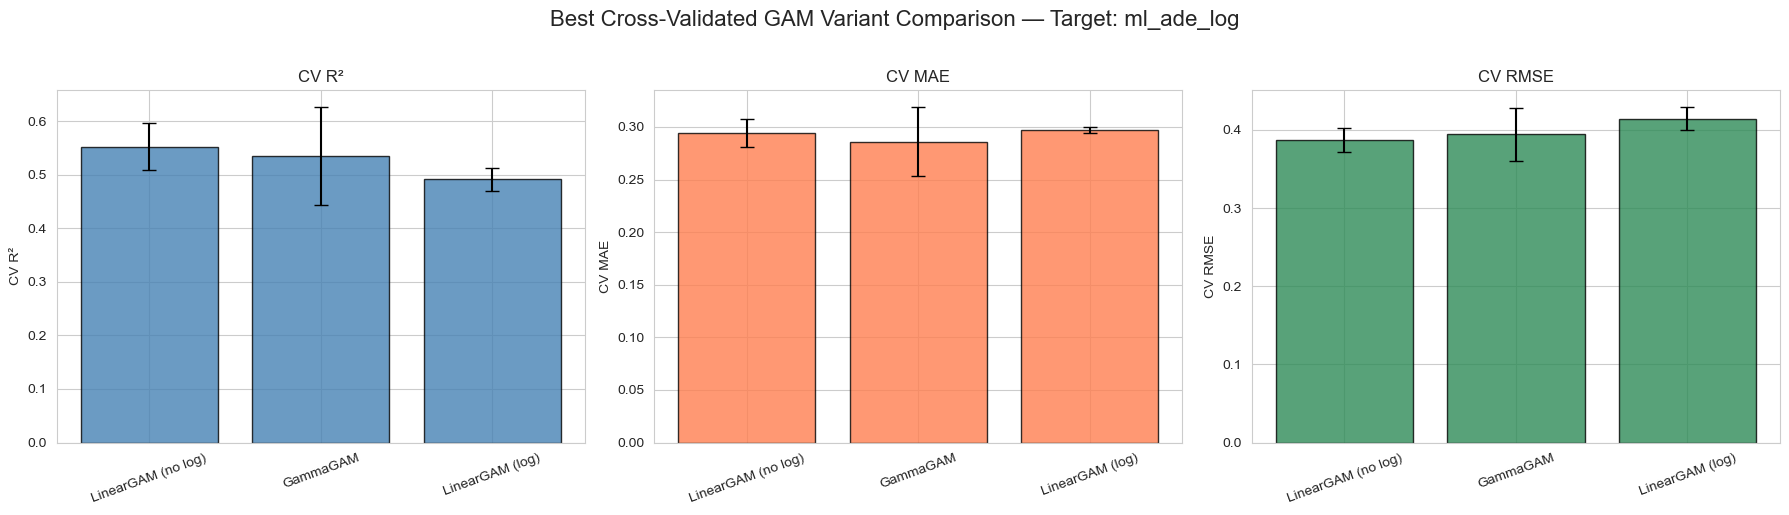

Variant comparison table saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_variant_cv_comparison_ml_ade_log.csv
Variant fold metrics saved to:   ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_variant_cv_fold_metrics_ml_ade_log.csv
Variant comparison plot saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/full_data_variant_cv_comparison_ml_ade_log.png
Full-data tuning trials saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_tuning_optuna_trials_ml_ade_log.csv
Full-data tuning summary saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/full_data_tuning_optuna_summary_ml_ade_log.json
Final GAM model fitted on all data using the selected retuned variant.


In [10]:
variant_results = []
trial_frames = []
comparison_fold_frames = []

variant_specs = [
    {
        'variant_name': 'LinearGAM (log)',
        'model_kind': 'linear',
        'target_mode': 'log',
        'y_values': y_log,
        'eligible': True,
        'skip_reason': None,
    },
    {
        'variant_name': 'LinearGAM (no log)',
        'model_kind': 'linear',
        'target_mode': 'raw',
        'y_values': y_raw,
        'eligible': True,
        'skip_reason': None,
    },
    {
        'variant_name': 'GammaGAM',
        'model_kind': 'gamma',
        'target_mode': 'raw',
        'y_values': y_raw,
        'eligible': bool((y_raw > 0).all()),
        'skip_reason': None if (y_raw > 0).all() else 'raw target contains non-positive values',
    },
]

for variant_idx, spec in enumerate(variant_specs, start=1):
    if not spec['eligible']:
        variant_results.append({
            'variant_name': spec['variant_name'],
            'model_kind': spec['model_kind'],
            'target_mode': spec['target_mode'],
            'status': 'skipped',
            'skip_reason': spec['skip_reason'],
        })
        print(f"Skipping {spec['variant_name']}: {spec['skip_reason']}")
        continue

    tuning_result = run_gam_optuna_tuning(
        X,
        spec['y_values'],
        model_kind=spec['model_kind'],
        target_mode=spec['target_mode'],
        seed=RANDOM_STATE + 100 + variant_idx,
        tuning_scope='full_data',
        variant_name=spec['variant_name'],
    )
    comparison_result = evaluate_variant_cv(
        X,
        spec['y_values'],
        model_kind=spec['model_kind'],
        target_mode=spec['target_mode'],
        params=tuning_result['best_params'],
        seed=RANDOM_STATE + 200 + variant_idx,
        variant_name=spec['variant_name'],
    )
    trial_frames.append(tuning_result['trial_results_df'])
    comparison_fold_frames.append(comparison_result['fold_metrics_df'])
    variant_results.append({
        'variant_name': spec['variant_name'],
        'model_kind': spec['model_kind'],
        'target_mode': spec['target_mode'],
        'status': 'completed',
        'best_params': tuning_result['best_params'],
        'best_cv_rmse': tuning_result['best_cv_rmse'],
        **comparison_result['summary'],
    })

completed_variants = [row for row in variant_results if row['status'] == 'completed']
if not completed_variants:
    raise ValueError('No eligible GAM variants completed tuning.')

selected_variant = min(completed_variants, key=lambda row: row['best_cv_rmse'])
print('Selected GAM variant based on lowest CV RMSE on original scale:')
print(selected_variant)

full_data_tuning_trials_df = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()
full_data_tuning_trials_path = TABLES_DIR / f'full_data_tuning_optuna_trials_{target_col}.csv'
full_data_tuning_trials_df.to_csv(full_data_tuning_trials_path, index=False)

variant_comparison_df = pd.DataFrame(completed_variants)[[
    'variant_name',
    'cv_r2_mean',
    'cv_r2_std',
    'cv_mae_mean',
    'cv_mae_std',
    'cv_rmse_mean',
    'cv_rmse_std',
    'best_cv_rmse',
]].sort_values('cv_rmse_mean').reset_index(drop=True)
display(variant_comparison_df)

variant_comparison_path = TABLES_DIR / f'full_data_variant_cv_comparison_{target_col}.csv'
variant_comparison_df.to_csv(variant_comparison_path, index=False)

variant_fold_metrics_df = pd.concat(comparison_fold_frames, ignore_index=True) if comparison_fold_frames else pd.DataFrame()
variant_fold_metrics_path = TABLES_DIR / f'full_data_variant_cv_fold_metrics_{target_col}.csv'
variant_fold_metrics_df.to_csv(variant_fold_metrics_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_specs = [
    ('cv_r2_mean', 'cv_r2_std', 'CV R²', 'steelblue'),
    ('cv_mae_mean', 'cv_mae_std', 'CV MAE', 'coral'),
    ('cv_rmse_mean', 'cv_rmse_std', 'CV RMSE', 'seagreen'),
]
for ax, (mean_col, std_col, title, color) in zip(axes, metric_specs):
    ax.bar(
        variant_comparison_df['variant_name'],
        variant_comparison_df[mean_col],
        yerr=variant_comparison_df[std_col],
        color=color,
        edgecolor='black',
        alpha=0.8,
        capsize=5,
    )
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(f'Best Cross-Validated GAM Variant Comparison — Target: {target_col}', fontsize=16, y=1.02)
plt.tight_layout()
variant_comparison_plot_path = PLOTS_DIR / f'full_data_variant_cv_comparison_{target_col}.png'
plt.savefig(variant_comparison_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Variant comparison table saved to: {variant_comparison_path}')
print(f'Variant fold metrics saved to:   {variant_fold_metrics_path}')
print(f'Variant comparison plot saved to: {variant_comparison_plot_path}')

full_data_tuning_summary = {
    'model_id': MODEL_ID,
    'run_name': RUN_NAME,
    'target_col': target_col,
    'raw_target_col': raw_target_col,
    'log_target_col': log_target_col,
    'selection_metric_name': 'rmse_original_scale',
    'variant_results': variant_results,
    'variant_comparison_path': str(variant_comparison_path),
    'variant_fold_metrics_path': str(variant_fold_metrics_path),
    'variant_comparison_plot_path': str(variant_comparison_plot_path),
    'selected_variant_name': selected_variant['variant_name'],
    'selected_variant_model_kind': selected_variant['model_kind'],
    'selected_variant_target_mode': selected_variant['target_mode'],
    'selected_best_params': selected_variant['best_params'],
    'selected_cv_rmse': selected_variant['best_cv_rmse'],
    'tuning_config': {
        'nfold': k_inner_fold,
        'n_trials': N_OPTUNA_TRIALS,
        'n_splines_range': [MIN_SPLINES, MAX_SPLINES],
        'spline_order_range': [MIN_SPLINE_ORDER, MAX_SPLINE_ORDER],
        'lam_range': [MIN_LAM, MAX_LAM],
        'random_state': RANDOM_STATE,
    },
}
full_data_tuning_summary_path = TABLES_DIR / f'full_data_tuning_optuna_summary_{target_col}.json'
full_data_tuning_summary_path.write_text(json.dumps(full_data_tuning_summary, indent=2))
print(f'Full-data tuning trials saved to: {full_data_tuning_trials_path}')
print(f'Full-data tuning summary saved to: {full_data_tuning_summary_path}')

selected_y = y_log if selected_variant['target_mode'] == 'log' else y_raw
final_scaler = StandardScaler()
X_scaled_all = final_scaler.fit_transform(X)
final_model = fit_gam_model(
    selected_variant['model_kind'],
    X_scaled_all,
    selected_y,
    selected_variant['best_params'],
)
print('Final GAM model fitted on all data using the selected retuned variant.')


## 6. Export Artifacts and Run Manifest


In [11]:
model_path = SAVE_DIR / f'gam_model_{target_col}.pkl'
with model_path.open('wb') as f:
    pickle.dump(final_model, f)

scaler_path = SAVE_DIR / f'gam_scaler_{target_col}.pkl'
with scaler_path.open('wb') as f:
    pickle.dump(final_scaler, f)

data_path = TABLES_DIR / f'model_data_with_oof_{target_col}.csv'
model_df_oof.to_csv(data_path, index=False)

manifest = build_run_manifest(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    feature_cols=feature_cols,
    save_dir=SAVE_DIR,
    plots_dir=PLOTS_DIR,
    tables_dir=TABLES_DIR,
    nested_resampling={
        'nested_cv_path': str(nested_path),
        'nested_cv_summary_path': str(nested_summary_path),
        'oof_predictions_path': str(oof_path),
        'oof_metrics_path': str(metrics_path),
        'model_data_with_oof_path': str(data_path),
    },
    final_model={
        'model_path': str(model_path),
        'scaler_path': str(scaler_path),
        'full_data_tuning_trials_path': str(full_data_tuning_trials_path),
        'full_data_tuning_summary_path': str(full_data_tuning_summary_path),
        'variant_comparison_path': str(variant_comparison_path),
        'variant_fold_metrics_path': str(variant_fold_metrics_path),
        'variant_comparison_plot_path': str(variant_comparison_plot_path),
        'selected_variant_name': selected_variant['variant_name'],
        'selected_variant_model_kind': selected_variant['model_kind'],
        'selected_variant_target_mode': selected_variant['target_mode'],
        'selected_best_params': selected_variant['best_params'],
        'selected_cv_rmse': selected_variant['best_cv_rmse'],
        'exported_model_name': selected_variant['variant_name'],
        'exported_model_kind': selected_variant['model_kind'],
        'exported_model_target_mode': selected_variant['target_mode'],
        'exported_model_selection_metric_name': 'lowest_cv_rmse',
        'exported_model_selection_metric_value': selected_variant['best_cv_rmse'],
    },
    analysis={
        'poor_well_quantile': POOR_WELL_QUANTILE,
    },
    extra_manifest_fields={
        'raw_target_col': raw_target_col,
        'log_target_col': log_target_col,
    },
)
manifest_path = write_manifest(manifest, TABLES_DIR, target_col)

print(f'Final GAM model saved to: {model_path}')
print(f'Final GAM scaler saved to: {scaler_path}')
print(f'Model data with OOF predictions saved to: {data_path}')
print(f'Run manifest saved to: {manifest_path}')
print('Exported model summary:')
print(f"- Name: {selected_variant['variant_name']}")
print(f"- Kind: {selected_variant['model_kind']}")
print(f"- Target mode: {selected_variant['target_mode']}")
print(f"- Selection metric: lowest_cv_rmse={selected_variant['best_cv_rmse']:.6f}")


Final GAM model saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_model_ml_ade_log.pkl
Final GAM scaler saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/gam_scaler_ml_ade_log.pkl
Model data with OOF predictions saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/model_data_with_oof_ml_ade_log.csv
Run manifest saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
